### Simple Concept

A **feature map** is the output produced by a convolution layer after applying a filter (kernel) to an image.

The filter looks for a particular pattern in the image, such as:

- Edges
- Lines
- Textures
- Simple shapes

The resulting feature map shows **where that pattern was detected** in the image.

### How it works

**Input Image → Convolution Filter → Feature Map**

For example, if a filter detects vertical edges:

- Strong activation → vertical edge is present
- Weak activation → vertical edge is not strongly present

So, a feature map helps us understand **what type of visual information a CNN is detecting**.

### What happens in different CNN layers?

**Early layers:**
- Detect simple features
- Edges
- Lines
- Basic patterns

**Middle layers:**
- Combine simple features
- Detect textures
- Shapes
- More complex patterns

**Deeper layers:**
- Combine these patterns further
- Detect higher-level structures
- Parts of objects and meaningful visual patterns

### Important Point

A feature map is **not the original image**.

It is a representation showing **where a particular learned feature is detected in the image**.

### Real-World Example

Suppose a CNN is classifying images of cats and dogs.

An early convolution layer may detect:

**Edges → curves → textures**

Later layers may combine these into:

**Ear shapes → eyes → fur patterns**

Deeper layers can combine these patterns to help recognize:

**Cat-like or dog-like features**

### Key Point

**Feature Map = A visual representation of the features detected by a CNN layer.**

Input shape: torch.Size([1, 1, 28, 28])
Feature map shape: torch.Size([1, 4, 28, 28])


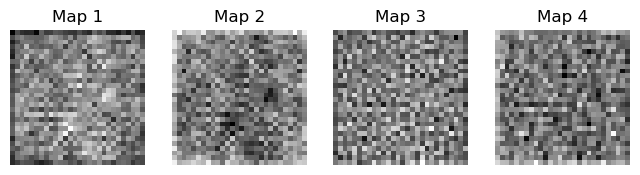

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Create a simple CNN layer
conv = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    padding=1
)

# Create a sample grayscale image
image = torch.rand(1, 1, 28, 28)

# Pass image through convolution
feature_maps = conv(image)

print("Input shape:", image.shape)
print("Feature map shape:", feature_maps.shape)

plt.figure(figsize=(8, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(feature_maps[0, i].detach(), cmap="gray")
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.show()

## Topic 2: Intermediate Activations

### Simple Concept

**Intermediate activations** are the outputs produced by the different layers of a CNN while an image passes through the network.

Instead of looking only at the final prediction, we can look **inside the CNN** and see what each layer is responding to.

### How it works

**Input Image → Layer 1 → Layer 2 → Layer 3 → Output**

Each layer produces an activation.

For example:

- **Early layer:** detects edges and simple patterns
- **Middle layer:** detects textures and shapes
- **Deeper layer:** detects more complex and meaningful patterns

So, intermediate activations help us understand **what the CNN is seeing at different stages**.


### Real-World Example

For a CNN identifying a **dog image**:

**Early layer:**
Detects edges and lines.

**Middle layer:**
Combines these into shapes and textures such as fur patterns.

**Deeper layer:**
Combines those patterns into meaningful structures such as an ear, eye, or face.

### Key Point

**Intermediate activation = What a CNN layer produces internally while processing an image.**

Visualizing these activations helps us understand **what the CNN is learning at different depths**.

First layer activation: torch.Size([1, 4, 28, 28])
Second layer activation: torch.Size([1, 8, 28, 28])


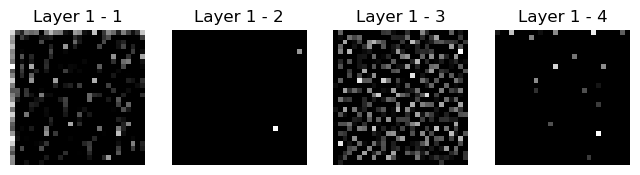

In [4]:

### Python Example

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Simple CNN
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(4, 8, kernel_size=3, padding=1),
    nn.ReLU()
)

# Sample grayscale image
image = torch.rand(1, 1, 28, 28)

# Get activation from first convolution layer
activation1 = model[0](image)

# Pass through ReLU
activation1_relu = model[1](activation1)

# Get activation from second convolution layer
activation2 = model[2](activation1_relu)

print("First layer activation:", activation1_relu.shape)
print("Second layer activation:", activation2.shape)

### Visualize an Intermediate Activation

plt.figure(figsize=(8, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(activation1_relu[0, i].detach(), cmap="gray")
    plt.title(f"Layer 1 - {i+1}")
    plt.axis("off")

plt.show()




```

**Output:**

```text
First layer activation: torch.Size([1, 4, 28, 28])
Second layer activation: torch.Size([1, 8, 28, 28])
```

Here:

- First convolution produces **4 activation maps**
- Second convolution produces **8 activation maps**
- These activations represent what each layer detected from the image

### Simple Concept

A **filter** (also called a **kernel**) is a small set of learnable values inside a CNN.

During training, the CNN learns these filter values so that different filters respond to different visual patterns.

**Filter → looks for a particular pattern**

For example, a filter may learn to respond strongly to:

- Horizontal edges
- Vertical edges
- Diagonal edges
- Textures
- Simple shapes

### What is Filter Visualization?

**Filter visualization** means looking at the learned values of CNN filters to understand what patterns the filters may be detecting.

For example:

```text
Input Image
     ↓
CNN Filter
     ↓
Detects a visual pattern
     ↓
Feature Map
```


### Important Point

The filters above are **randomly initialized**, so they do not represent meaningful learned patterns yet.

After training, the filter values are adjusted by the CNN.

Therefore:

**Before training → random filters**

**After training → learned filters**

### Real-World Example

Suppose a CNN is trained to recognize animals.

An early CNN layer may learn filters that respond to:

**Edges → curves → simple textures**

Later layers combine these features to recognize more complex patterns.

### Key Point

**Filter visualization = Looking at the learned CNN filters to understand what visual patterns they may detect.**

Filter visualization mainly helps us understand **what the CNN's learned filters look like**, while activation/feature-map visualization shows **where those learned features are detected in an image**.

Filter shape: torch.Size([4, 1, 3, 3])


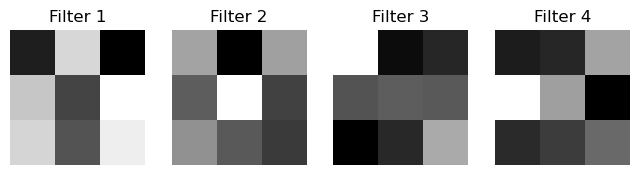

In [6]:

### Python Example

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Create a convolution layer
conv = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3
)

# Get the learned filter weights
filters = conv.weight.detach()

print("Filter shape:", filters.shape)


### Visualize the Filters

plt.figure(figsize=(8, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(filters[i, 0], cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.show()


```

**Output:**

```text
Filter shape: torch.Size([4, 1, 3, 3])
```

Here:

- `4` → number of filters
- `1` → input channel
- `3 × 3` → filter size

So this layer contains **4 filters**, each of size **3 × 3**.

### Simple Concept

**Activation visualization** means displaying the output of a CNN layer to see **which parts or patterns of an image activate the neurons strongly**.

When an image passes through a CNN:

**Image → CNN Layer → Activations**

A strong activation means that the neuron has responded strongly to a particular feature.

### What does it show?

Activation visualization helps us see **what the CNN is responding to in the image**.

For example:

- Early layer → edges and simple patterns
- Middle layer → textures and shapes
- Deeper layer → more complex patterns


### What is the difference from Feature Maps?

They are closely related.

**Feature map:**
The output produced by a convolution filter, showing where a feature is detected.

**Activation:**
The response/output of a neuron or layer after processing the input.

In CNN visualization, the terms are often used very closely because feature maps are commonly visualized as activations.

### Real-World Example

Imagine a CNN looking at a **car image**.

An early layer may activate around:

**Edges → wheels → windows**

A deeper layer may activate around:

**Wheel shapes → car body → larger vehicle patterns**

By visualizing these activations, we can see **which regions of the image are important to the CNN at different layers**.

### Key Point

**Activation visualization = Visualizing the CNN's internal responses to an input image.**

It helps us understand **what the CNN is responding to and how its understanding changes from early layers to deeper layers**.

Activation shape: torch.Size([1, 4, 28, 28])


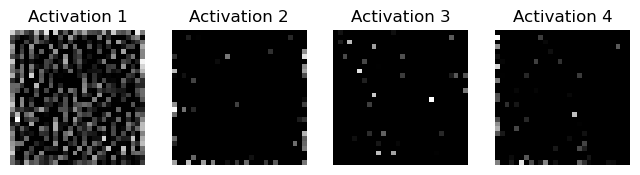

In [7]:

### Python Example

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Simple CNN
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, padding=1),
    nn.ReLU()
)

# Sample image
image = torch.rand(1, 1, 28, 28)

# Get activation
activation = model(image)

print("Activation shape:", activation.shape)


### Visualize the Activations

plt.figure(figsize=(8, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(activation[0, i].detach(), cmap="gray")
    plt.title(f"Activation {i+1}")
    plt.axis("off")

plt.show()


```

**Output:**

```text
Activation shape: torch.Size([1, 4, 28, 28])
```

This means the CNN produced **4 activation maps**.

## Topic 5: Saliency Concepts

### Simple Concept

**Saliency** means identifying the parts of an image that are **most important for the CNN's prediction**.

In simple words:

> **Saliency tells us which pixels or regions of an image influenced the model's decision the most.**

For example, if a CNN classifies an image as a **dog**, a saliency visualization may highlight areas around the dog's face, ears, or body.

### How it works

The basic idea is:

**Image → CNN Prediction → Find important pixels → Saliency Map**

A saliency map shows which parts of the image have a stronger influence on the prediction.

Usually:

- **High saliency** → more important to the prediction
- **Low saliency** → less important to the prediction


### What is happening?

The important steps are:

**1. `requires_grad=True`**

Allows PyTorch to calculate how the prediction changes with respect to the input pixels.

**2. `class_score.backward()`**

Calculates gradients for the selected class.

**3. `image.grad`**

Contains the gradient of the prediction with respect to each input pixel.

**4. `abs()`**

We use the absolute value so that both positive and negative influences can be represented as importance.



### Real-World Example

Suppose a CNN receives this image:

**Dog image → CNN → "Dog"**

A saliency map might show strong importance around:

**Eyes + ears + face + body**

This helps us understand **which parts of the image contributed to the prediction**.

### Why is Saliency Useful?

Saliency can help us:

- Understand model decisions
- Check whether the CNN is focusing on meaningful image regions
- Investigate unexpected predictions
- Debug model behavior

### Important Point

Saliency does **not** mean the CNN is literally "thinking" about those pixels.

It shows which input regions have a strong **gradient-based influence** on the selected prediction.

### Key Point

**Saliency = Identifying which parts of an input image are important for a CNN's prediction.**



Saliency shape: torch.Size([1, 1, 28, 28])


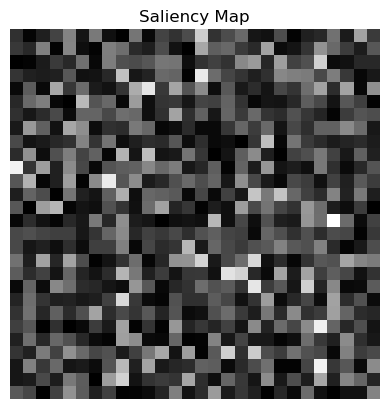

In [8]:

### Python Example

import torch
import torch.nn as nn

# Simple CNN
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(4 * 28 * 28, 10)
)

# Create an input image
image = torch.rand(1, 1, 28, 28, requires_grad=True)

# Forward pass
output = model(image)

# Select one predicted class
class_score = output[0, output.argmax()]

# Calculate gradients
class_score.backward()

# Get importance of each pixel
saliency = image.grad.abs()

print("Saliency shape:", saliency.shape)
### Visualize the Saliency Map

import matplotlib.pyplot as plt

plt.imshow(saliency[0, 0].detach(), cmap="gray")
plt.title("Saliency Map")
plt.axis("off")
plt.show()


## Topic 6: Grad-CAM Introduction

### Simple Concept

**Grad-CAM (Gradient-weighted Class Activation Mapping)** is a visualization technique used to understand **which regions of an image influenced a CNN's prediction**.

Instead of highlighting individual pixels like a basic saliency map, Grad-CAM creates a **heatmap over the image**.

### Basic Idea

**Input Image → CNN → Prediction → Gradients + Feature Maps → Grad-CAM Heatmap**

The heatmap shows the regions that were important for a particular class prediction.

For example:

**Image → CNN predicts "Dog"**

Grad-CAM may highlight the region containing the:

**Dog's face and body**

This helps us understand whether the CNN focused on the correct part of the image.

### Why Grad-CAM is useful

Grad-CAM is useful for:

- Understanding CNN predictions
- Visualizing important image regions
- Checking whether the model focuses on meaningful features
- Investigating incorrect predictions
- Making CNN decisions easier to interpret

### How it differs from Saliency

**Saliency:**

Focuses on the importance of individual input pixels.

**Grad-CAM:**

Uses CNN feature maps and gradients to identify **important regions** of the image.

So, in simple terms:

**Saliency → Which pixels are important?**

**Grad-CAM → Which image regions are important?**

### Python Example

Grad-CAM is normally applied to a **trained CNN**, because the goal is to understand an actual model prediction.

The basic concept involves:

```python
# Conceptual Grad-CAM steps

# 1. Pass image through CNN
output = model(image)

# 2. Select the target class
class_score = output[0, target_class]

# 3. Calculate gradients
class_score.backward()

# 4. Get feature maps from a CNN layer

# 5. Combine gradients with feature maps

# 6. Create a heatmap

# 7. Overlay heatmap on the original image
```

The important idea is that Grad-CAM combines:

**Feature Maps + Gradients → Importance Heatmap**

### Real-World Example

Suppose a CNN receives an image of a **dog**.

The model predicts:

**Dog: 95%**

Grad-CAM can create a heatmap showing that the model mainly focused on the **dog's face and body**.

If the model instead focuses on the **background**, that could indicate that the model may have learned an unwanted shortcut.

### CNN Visualization Progression

The visualization techniques in this notebook help us understand CNNs at different levels:

**Feature Maps**
→ What features are detected?

**Intermediate Activations**
→ What is each layer responding to?

**Filter Visualization**
→ What do the learned filters look like?

**Activation Visualization**
→ Which features activate for an image?

**Saliency**
→ Which pixels influence the prediction?

**Grad-CAM**
→ Which regions influence the prediction?

### Main CNN Learning Pattern

**Early layers → Edges / simple patterns**

↓

**Middle layers → Textures / shapes**

↓

**Deeper layers → Higher-level patterns**

This is the main idea you should remember from CNN visualization.

### Key Point

**Grad-CAM = A technique that creates a heatmap showing which regions of an image were important for a CNN's specific prediction.**